# Notebook 06 — H₂ Dissociation NEB
## Hastelloy N | Hydrogen Interaction Study


**This notebook covers:**
- The nudged elastic band (NEB) method and minimum energy path (MEP)
- The dissociation reaction: H₂* → H* + H* on Hastelloy N (111)
- Finding the true final state by individual H atom minimization (Option B)
- Climbing image NEB (CINEB) — converging to the true saddle point
- Extracting the activation barrier E_a and reaction energy ΔE



---
## 1. Theory & Background
---

### 1.1 The Nudged Elastic Band Method

The nudged elastic band (NEB) method finds the minimum energy path (MEP) between two known states on a potential energy surface [1,2]. The MEP is the lowest-energy pathway connecting the initial state (IS) to the final state (FS). The highest point on the MEP is the transition state (TS), and its energy above the IS is the activation barrier E_a.

**How NEB works:**
1. Generate N replicas by linear interpolation (IDPP) between IS and FS
2. Connect adjacent replicas with spring forces (the elastic band)
3. Minimize all replicas simultaneously: true forces act perpendicular to the band (move replicas toward MEP); spring forces act parallel to the band (keep replicas evenly spaced). The nudging projects these components apart [1,2].
4. At convergence, replicas lie along the MEP

**Climbing image NEB (CINEB):** After initial NEB convergence, the highest-energy replica is identified, its spring forces removed, and it is pushed uphill to the true saddle point [3]. This gives an accurate E_a.


### 1.2 The Dissociation Reaction

We compute the MEP for:

H₂* (bridge) → H* + H* (hollow sites)

**Initial state (IS):** H₂ at the most stable site — most stable molecular adsorption site from Notebook 05 (E_ads (eV)).

**Final state (FS):** Two separate H atoms at their optimal hollow sites, found by individual H atom minimizations .

| Quantity | Symbol | Definition |
|---------|--------|------------|
| Activation barrier | E_a | E(TS) − E(IS) |
| Reaction energy | ΔE | E(FS) − E(IS) |

If E_a ≈ 0: H₂ dissociates barrierlessly. If ΔE < 0: dissociation is exothermic.

**Key references:** [1,2,4,5]

### 1.3 Finding the Final State — Option B

We cannot assume both H atoms sit at FCC hollows — on an alloy surface optimal sites depend on local composition [4,5,6].

**Option B protocol:**
1. Place one H atom at each candidate site (FCC hollow, HCP hollow, top-Ni, bridge) on the clean slab
2. Minimize each independently — gives E_ads(H*) at each site
3. The two most stable non-adjacent sites form the NEB final state
4. Place 2 H atoms at these sites and minimize — this is the FS

**Why non-adjacent?** Two H atoms at adjacent sites repel each other through the surface. The final state must have H atoms separated by at least one lattice spacing [4,5].

**H atom reference energy:** E_ads(H*) = E(slab+H) − E(clean_slab) − 0.5×E(H₂_gas). The 0.5 factor comes from H₂ → 2H*, so each H costs half the H₂ energy [4,5].

**Key references:** [4,5,6]

---
## 2. Execution Strategy
---

### What We Are Doing in This Notebook

```
3.1  Imports, parameters
       — read ALL previous results from logs, no hardcoding
3.2  Build individual H atom structures (7 sites) + submit
3.3  Parse H atom jobs — find most stable single-H sites
3.4  Build NEB IS and FS + submit FS minimization
       IS: H2* at bridge (NB05 physisorbed minimum)
       FS: 2H* at local hollows flanking bridge (minimized)
3.5  Verify IS and FS — geometry checks, energies
3.6  (removed — merged into 3.5)
3.7  Write ASE CINEB script (IDPP interpolation, 1 A100)
3.8  Submit NEB job
3.9  Parse NEB results — E_a, delta_E, path
3.10 Plot MEP
3.11 Decision cell
```

---
## 3. Code
---

### 3.1 — Imports, Parameters & Read All Previous Results

In [14]:
import numpy as np
import os
import json
import subprocess
import shutil
import matplotlib.pyplot as plt
from ase.io import read
from collections import Counter
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD        = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL_LAMMPS = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
MACE_MODEL_ASE    = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model'
MACE_MODEL        = MACE_MODEL_LAMMPS  # default for LAMMPS scripts
KOKKOS_FLAGS      = ['-k', 'on', 'g', '1', '-sf', 'kk',
                     '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping ────────────────────────────────────────
ELEM_STR    = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'
E2T = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}
MASSES = {
    1:(26.9815,'Al'), 2:(10.8110,'B'),  3:(12.0110,'C'),
    4:(51.9961,'Cr'), 5:(55.8450,'Fe'), 6:(95.9600,'Mo'),
    7:(58.6934,'Ni'), 8:( 1.0080,'H'),
}

# ── NEB parameters ───────────────────────────────────────────
N_REPLICAS   = 18       # intermediate images
SPRING_CONST = 2.0     # eV/Å²
NEB_FTOL     = 0.05    # eV/Å — NEB convergence
N1_STEPS     = 5000    # phase 1: regular NEB steps
NEB_STEPS    = 10000    # phase 2: CINEB steps

# ── Geometry constants ───────────────────────────────────────
Z_FREEZE_CUTOFF = 22.115  # Å — frozen layer cutoff (NB04)
H_ATOM_HEIGHT   = 1.5     # Å above surface for single H atom
NN_CUTOFF       = 3.2     # Å — nearest-neighbor cutoff

# ── Minimization settings ────────────────────────────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths ───────────────────────────────────────────────
#SLAB_RELAXED = 'structures/notebook04/hastelloy_n_slab_relaxed.lammps'
# CORRECT — same slab NB08 used
SLAB_RELAXED = 'structures/notebook05-adsorption-energy/111/clean_slab_reminimized.lammps'
NEB_IS_FILE  = 'structures/notebook06-Neb-dissociation/111/neb_initial.lammps'
NEB_LOG      = 'results/notebook06-Neb-dissociation/111/neb.log'
NEB_PATH_OUT = 'results/notebook06-Neb-dissociation/111/neb_path.dat'
# H_ATOM_SITES = site_data['h_atom_sites']
# print(f'H_ATOM_SITES loaded from NB05: {H_ATOM_SITES}')

for d in ['structures/notebook06-Neb-dissociation/111', 'results/notebook06-Neb-dissociation/111',
          'lammps_scripts/notebook06-Neb-dissociation/111', 'slurm_scripts/notebook06-Neb-dissociation/111']:
    os.makedirs(d, exist_ok=True)

# ── Helper: parse energy log ──────────────────────────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ═══════════════════════════════════════════════════════════
# READ ALL PREVIOUS RESULTS FROM LOGS — NO HARDCODING
# ═══════════════════════════════════════════════════════════
print('Reading previous notebook results from logs...')
print()

# NB05: E_clean_slab
res = parse_energy_log('results/notebook05-adsorption-energy/111/ads_clean_slab.log')
if res:
    E_CLEAN_SLAB = res['pe_final_eV']
    print(f'E_clean_slab  : {E_CLEAN_SLAB:.6f} eV  [ads_clean_slab.log]')
else:
    raise FileNotFoundError('results/notebook05-adsorption-energy/111/ads_clean_slab.log not found.')

# NB05: E_H2_gas
res = parse_energy_log('results/notebook05-adsorption-energy/111/ads_h2_gas.log')
if res:
    E_H2_GAS = res['pe_final_eV']
    print(f'E_H2_gas      : {E_H2_GAS:.6f} eV  [ads_h2_gas.log]')
else:
    raise FileNotFoundError('results/notebook05-adsorption-energy/111/ads_h2_gas.log not found.')

# NB05: E_IS — most stable adsorption site
E_IS = None
E_ADS_best = 0.0  # least stable possible
best_site_log = None

for site_log in ['ads_bridge.log', 'ads_top_cr.log', 'ads_top_ni.log', 'ads_top_fe.log',
                 'ads_top_b.log', 'ads_top_c.log', 'ads_top_mo.log',
                 'ads_fcc_hollow.log', 'ads_hcp_hollow.log']:
    res = parse_energy_log(f'results/notebook05-adsorption-energy/111/{site_log}')
    if res:
        E_IS_candidates = res['pe_final_eV']
        E_ads_cand = E_IS_candidates - E_CLEAN_SLAB - E_H2_GAS
        if E_ads_cand < E_ADS_best:
            E_ADS_best    = E_ads_cand
            E_IS          = E_IS_candidates
            best_site_log = site_log

if E_IS is None:
    raise FileNotFoundError('No NB05 adsorption log found.')

print(f'E_IS (most stable): {E_IS:.6f} eV  [{best_site_log}]')
print(f'E_ads              : {E_ADS_best:.4f} eV')

# ── Load relaxed slab ─────────────────────────────────────────
# with open('results/notebook05-adsorption-energy/111/site_coords.json') as f:
#     site_data = json.load(f)

# z_surf       = site_data['z_surf']
# z_H2         = site_data['z_H2']
# min_dist     = site_data['min_dist']
# SITE_COORDS  = {k: tuple(v) for k, v in site_data['site_coords'].items()}
# H_ATOM_SITES = site_data['h_atom_sites']

# print('Site coordinates loaded from NB05:')
# for name, (x, y) in SITE_COORDS.items():
#     print(f'  {name:12s}: ({x:.4f}, {y:.4f})')
# print(f'H_ATOM_SITES : {H_ATOM_SITES}')
# print(f'z_surf = {z_surf:.4f} Å  |  z_H_atom = {z_surf + H_ATOM_HEIGHT:.4f} Å')

with open(f'results/notebook05-adsorption-energy/111/site_coords.json') as f:
    site_data = json.load(f)

z_surf       = site_data['z_surf']
z_H2         = site_data['z_H2']
min_dist     = site_data['min_dist']
H_ATOM_SITES = site_data['h_atom_sites']

# Use relaxed H positions if available, fall back to nominal
if 'site_coords_relaxed' in site_data:
    SITE_COORDS = {k: tuple(v) for k, v in site_data['site_coords_relaxed'].items()}
    print('SITE_COORDS loaded from relaxed H positions (NB05 post-relaxation):')
else:
    SITE_COORDS = {k: tuple(v) for k, v in site_data['site_coords'].items()}
    print('SITE_COORDS loaded from nominal placement (NB05 pre-relaxation):')

# Also load relaxed labels for reporting
RELAXED_LABELS = site_data.get('site_labels_relaxed', {})

for name, (x, y) in SITE_COORDS.items():
    rlbl = RELAXED_LABELS.get(name, name)
    match = '' if rlbl in name or name in rlbl else f'  ← placed as {name}, relaxed to {rlbl}'
    print(f'  {name:12s}: ({x:.4f}, {y:.4f}){match}')

# ── write_min_frozen helper ───────────────────────────────────
def write_min_frozen(job_name, input_file, output_file):
    lines = [
        'units metal', 'atom_style atomic', 'newton on', 'boundary p p f', '',
        f'read_data      {input_file}', '',
        f'pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}',
        f'pair_coeff     * * {ELEM_STR}', '',
        'neighbor       2.0 bin', 'neigh_modify   every 1 delay 0 check yes', '',
        f'region         frozen_reg  block  INF INF  INF INF  EDGE  {Z_FREEZE_CUTOFF}',
        'group          frozen_atoms  region  frozen_reg',
        'group          free_atoms    subtract  all  frozen_atoms',
        'fix            freeze  frozen_atoms  setforce  0.0  0.0  0.0', '',
        'thermo         50', 'thermo_style   custom step pe fmax', '',
        f'minimize       {ETOL}  {FTOL}  {MAXITER}  {MAXEVAL}', '',
        'variable  pe_final  equal  pe',
        'variable  fmax_f    equal  fmax',
        'variable  natoms    equal  atoms', '',
        'print "ENERGY_RESULTS_START"',
        f'print "  job_name         : {job_name}"',
        'print "  pe_final_eV      : ${pe_final}"',
        'print "  fmax_eV_per_Ang  : ${fmax_f}"',
        'print "  natoms           : ${natoms}"',
        'print "ENERGY_RESULTS_END"', '',
        f'write_data     {output_file}',
    ]
    script = '\n'.join(lines) + '\n'
    path = f'lammps_scripts/notebook06-Neb-dissociation/111/min_{job_name}.lammps'
    with open(path, 'w') as f:
        f.write(script)
    return path

ASE version : 3.27.0
NumPy       : 2.4.3
Reading previous notebook results from logs...

E_clean_slab  : -2386.723357 eV  [ads_clean_slab.log]
E_H2_gas      : -6.790499 eV  [ads_h2_gas.log]
E_IS (most stable): -2393.710577 eV  [ads_bridge.log]
E_ads              : -0.1967 eV
SITE_COORDS loaded from relaxed H positions (NB05 post-relaxation):
  top_ni      : (4.6029, 7.7766)
  top_mo      : (7.1253, 8.2202)
  top_cr      : (4.9293, 11.8604)  ← placed as top_cr, relaxed to hollow
  top_fe      : (5.4383, 6.1618)  ← placed as top_fe, relaxed to bridge
  top_c       : (4.4637, 4.1673)  ← placed as top_c, relaxed to hollow
  bridge      : (11.4318, 6.4592)  ← placed as bridge, relaxed to top_ni
  fcc_hollow  : (2.4689, 7.7615)  ← placed as fcc_hollow, relaxed to top_ni
  hcp_hollow  : (2.4385, 7.7288)  ← placed as hcp_hollow, relaxed to top_ni


### 3.2 - Build Individual H Atom Structures and Submit

> One H atom at each of 4 candidate sites. 4 parallel SLURM jobs.

In [15]:
# ─────────────────────────────────────────────────────────────
# Build slab + single H atom at each site and submit
# E_ads(H*) = E(slab+H) - E(clean_slab) - 0.5*E(H2_gas)
# ─────────────────────────────────────────────────────────────
kk = ' '.join(KOKKOS_FLAGS)
sc = SLURM_CONFIG
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH' for p in sc['ld_paths'])
z_H_atom = z_surf + H_ATOM_HEIGHT

def write_slab_h_atom(site_name, x_site, y_site):
    outfile   = f'structures/notebook06-Neb-dissociation/111/h_atom_{site_name}.lammps'
    slab      = read(SLAB_RELAXED, format='lammps-data', style='atomic')
    slab_syms = list(slab.get_chemical_symbols())
    slab_pos  = slab.get_positions()
    L         = slab.cell.lengths()

    all_syms  = slab_syms + ['H']
    h_pos     = np.array([x_site % L[0], y_site % L[1], z_H_atom])
    all_pos   = np.vstack([slab_pos, h_pos])
    with open(outfile, 'w') as f:
        f.write(f'# Hastelloy N slab + 1H at {site_name} — Notebook 06\n\n')
        f.write(f'{len(all_syms)} atoms\n{len(MASSES)} atom types\n\n')
        f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
        f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
        f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(all_syms, all_pos), 1):
            f.write(f'{i}  {E2T[sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')
    return outfile

h_atom_jobs = {}

print(f'Submitting {len(H_ATOM_SITES)} single-H minimization jobs...')
print(f'H atom height: {H_ATOM_HEIGHT} A above z_surf = {z_surf:.4f} A')
print()

for site in H_ATOM_SITES:
    x, y   = SITE_COORDS[site]
    struct = write_slab_h_atom(site, x, y)
    script = write_min_frozen(f'h_atom_{site}', struct,
                               f'structures/notebook06-Neb-dissociation/111/h_atom_{site}_relaxed.lammps')
    slurm_lines = [
        '#!/bin/bash',
        f'#SBATCH --job-name=nb06_h_{site}',
        f'#SBATCH --ntasks={sc["ntasks"]}',
        f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}',
        f'#SBATCH --gres=gpu:{sc["gpu"]}',
        f'#SBATCH --partition=multigpu',
        '#SBATCH --time=01:00:00',
        f'#SBATCH --output=results/notebook06-Neb-dissociation/111/slurm_h_atom_{site}_%j.out',
        f'module load OpenMPI/{sc["openmpi_ver"]}',
        f'module load cuda/{sc["cuda_version"]}',
        'source ~/miniforge3/etc/profile.d/conda.sh',
        f'conda activate {sc["conda_env"]}',
        ld,
        f'cd {os.getcwd()}',
        f'{LAMMPS_CMD} {kk} -in {script} -log results/notebook06-Neb-dissociation/111/h_atom_{site}.log',
        f'echo "h_atom_{site} done: $(date)"',
    ]
    sp = f'slurm_scripts/notebook06-Neb-dissociation/111/run_h_atom_{site}.sh'
    with open(sp, 'w') as f:
        f.write('\n'.join(slurm_lines) + '\n')
    os.chmod(sp, 0o755)
    result = subprocess.run(['sbatch', sp], capture_output=True, text=True)
    if result.returncode == 0:
        jid = result.stdout.strip().split()[-1]
        h_atom_jobs[site] = jid
        print(f'  ok h_atom_{site:12s} -> Job {jid}')
    else:
        print(f'  FAIL h_atom_{site:12s} -> {result.stderr.strip()}')

print('\nAfter all jobs finish, run cell 3.3.')

Submitting 8 single-H minimization jobs...
H atom height: 1.5 A above z_surf = 38.8140 A

  ok h_atom_top_ni       -> Job 7421339
  ok h_atom_top_mo       -> Job 7421340
  ok h_atom_top_cr       -> Job 7421341
  ok h_atom_top_fe       -> Job 7421342
  ok h_atom_top_c        -> Job 7421343
  ok h_atom_bridge       -> Job 7421344
  ok h_atom_fcc_hollow   -> Job 7421345
  ok h_atom_hcp_hollow   -> Job 7421346

After all jobs finish, run cell 3.3.


### 3.3 — Parse H Atom Jobs and Find Most Stable Sites

In [20]:
# ─────────────────────────────────────────────────────────────
# Parse single-H logs and rank sites by E_ads(H*)
# ─────────────────────────────────────────────────────────────
h_energies = {}
h_eads     = {}

print('Single H atom adsorption energies')
print('E_ads(H*) = E(slab+H) - E(clean_slab) - 0.5*E(H2_gas)')
print('=' * 60)

for site in H_ATOM_SITES:
    res = parse_energy_log(f'results/notebook06-Neb-dissociation/111/h_atom_{site}.log')
    if res and 'pe_final_eV' in res:
        h_energies[site] = res['pe_final_eV']
        h_eads[site]     = h_energies[site] - E_CLEAN_SLAB - 0.5*E_H2_GAS
        fmax = res.get('fmax_eV_per_Ang', 0)
        print(f'  {site:12s}  E={h_energies[site]:.6f} eV  '
              f'E_ads={h_eads[site]:.4f} eV  fmax={fmax:.2e}')
    else:
        print(f'  {site:12s}  NOT FOUND')

if len(h_eads) < len(H_ATOM_SITES):
    raise RuntimeError('Not all H atom jobs finished. Wait and rerun this cell.')

# ── Rank sites ────────────────────────────────────────────────
ranked = sorted(h_eads, key=h_eads.get)

print()
print('Ranked (most stable first):')
for i, site in enumerate(ranked, 1):
    print(f'  {i}. {site:12s}  E_ads = {h_eads[site]:.4f} eV')

# ── Update SITE_COORDS with actual relaxed H positions ────────
print('\nUpdating SITE_COORDS from relaxed single-H structures:')
for site in H_ATOM_SITES:
    rpath = f'structures/notebook06-Neb-dissociation/111/h_atom_{site}_relaxed.lammps'
    if not os.path.exists(rpath):
        print(f'  {site:12s}  relaxed file not found — keeping nominal coords')
        continue
    slab = read(rpath, format='lammps-data', style='atomic')
    syms = np.array(slab.get_chemical_symbols())
    hpos = slab.get_positions()[syms == 'H']
    if len(hpos) == 1:
        old = SITE_COORDS[site]
        SITE_COORDS[site] = (hpos[0][0], hpos[0][1])
        drift = np.sqrt((hpos[0][0]-old[0])**2 + (hpos[0][1]-old[1])**2)
        flag  = '  ← DRIFTED' if drift > 0.3 else ''
        print(f'  {site:12s}  ({hpos[0][0]:.4f}, {hpos[0][1]:.4f})  '
              f'drift={drift:.4f} A{flag}')

# ── Pick best non-adjacent pair ───────────────────────────────
H_SEP_THRESHOLD = 2.5

best1       = ranked[0]
x1, y1      = SITE_COORDS[best1]
best2, sep2 = None, None

for candidate in ranked[1:]:
    x2, y2 = SITE_COORDS[candidate]
    sep = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    if sep > H_SEP_THRESHOLD:
        best2, sep2 = candidate, sep
        break
    print(f'  Skipping {candidate} — too close to {best1} ({sep:.3f} A)')

if best2 is None:
    raise RuntimeError(
        f'No second H site with separation > {H_SEP_THRESHOLD} A. '
        'Extend H_ATOM_SITES or lower H_SEP_THRESHOLD.')

x2, y2 = SITE_COORDS[best2]
print(f'\nFS site 1 : {best1:12s}  E_ads = {h_eads[best1]:.4f} eV  '
      f'xy=({x1:.4f}, {y1:.4f})')
print(f'FS site 2 : {best2:12s}  E_ads = {h_eads[best2]:.4f} eV  '
      f'xy=({x2:.4f}, {y2:.4f})')
print(f'H-H separation : {sep2:.4f} A')
print('\nRun cell 3.4.')

Single H atom adsorption energies
E_ads(H*) = E(slab+H) - E(clean_slab) - 0.5*E(H2_gas)
  top_ni        E=-2390.736333 eV  E_ads=-0.6177 eV  fmax=2.14e-07
  top_mo        E=-2390.736333 eV  E_ads=-0.6177 eV  fmax=2.25e-07
  top_cr        E=-2390.601212 eV  E_ads=-0.4826 eV  fmax=1.77e-07
  top_fe        E=-2390.798823 eV  E_ads=-0.6802 eV  fmax=2.72e-07
  top_c         E=-2390.297913 eV  E_ads=-0.1793 eV  fmax=2.21e-07
  bridge        E=-2390.321132 eV  E_ads=-0.2025 eV  fmax=3.17e-07
  fcc_hollow    E=-2390.289302 eV  E_ads=-0.1707 eV  fmax=2.62e-07
  hcp_hollow    E=-2390.275909 eV  E_ads=-0.1573 eV  fmax=2.04e-07

Ranked (most stable first):
  1. top_fe        E_ads = -0.6802 eV
  2. top_ni        E_ads = -0.6177 eV
  3. top_mo        E_ads = -0.6177 eV
  4. top_cr        E_ads = -0.4826 eV
  5. bridge        E_ads = -0.2025 eV
  6. top_c         E_ads = -0.1793 eV
  7. fcc_hollow    E_ads = -0.1707 eV
  8. hcp_hollow    E_ads = -0.1573 eV

Updating SITE_COORDS from relaxed single-H

In [17]:
# def describe_site(xy, surf_pos, surf_syms, z_surf):
#     mask  = np.abs(surf_pos[:, 2] - z_surf) < 1.5
#     s_pos = surf_pos[mask]
#     s_sym = surf_syms[mask]
#     dists = np.sqrt(np.sum((s_pos[:, :2] - np.array(xy))**2, axis=1))
#     idx   = np.argsort(dists)[:3]
#     return '  '.join(f'{s_sym[i]}({dists[i]:.2f}A)' for i in idx)

# print(f'\nFS site 1 : {best1:12s}  E_ads={h_eads[best1]:.4f} eV  '
#       f'neighbors={describe_site((x1,y1), surf_pos, surf_syms, z_surf)}')
# print(f'FS site 2 : {best2:12s}  E_ads={h_eads[best2]:.4f} eV  '
#       f'neighbors={describe_site((x2,y2), surf_pos, surf_syms, z_surf)}')
# print(f'H-H separation : {sep2:.4f} A')

# print(f"""You report what is actually there rather than forcing a label that may be ambiguous on a disordered surface.
# You can visually confirm in OVITO and call it a Ni-Mo bridge or hollow site in your paper based on what you see.""")

In [21]:
# ── True site identification using site_identifier ────────────
import sys
sys.path.append('.')

try:
    from models.site_identifier import identify_adsorption_site
except ImportError:
    print('ERROR: site_identifier.py not found in project root.')
    raise

h_true_sites = {}

print('\nTrue site identification (chemisorbed H*):')
print(f'  {"Nominal site":15s}  {"True label":35s}  {"Neighbors"}')
print('  ' + '-' * 80)

for site in H_ATOM_SITES:
    rpath = (f'structures/notebook06-Neb-dissociation/'
             f'/111/h_atom_{site}_relaxed.lammps')
    if not os.path.exists(rpath):
        print(f'  {site:15s}  relaxed file not found')
        continue
    try:
        result = identify_adsorption_site(
            rpath, adsorbate='H', mode='auto')
        s  = result[0]
        nn = [{'element': e, 'distance': round(d, 4), 'index': int(i)}
              for e, d, i in s['neighbors']]
        nn_str = '  '.join(f'{e}({d:.2f}A)' for e, d, i in s['neighbors'])

        h_true_sites[site] = {
            'nominal_label'   : site,
            'true_label'      : s['label'],
            'composition'     : s['composition'],
            'mode'            : s['mode'],
            'site_type'       : s['site_type'],
            'hollow_type'     : s.get('hollow_type') or '',
            'subsurf_element' : s.get('subsurf_element') or '',
            'z_above_surface' : round(s.get('z_above_surface', 0.0), 4),
            'E_ads_eV'        : round(h_eads.get(site, 0.0), 6),
            'neighbors'       : nn,
        }

        flag = '  <- DRIFTED' if (s['site_type'] != 'atop'
               and site.startswith('top')) else ''
        print(f'  {site:15s}  {s["label"]:35s}  [{nn_str}]{flag}')
    except Exception as e:
        print(f'  {site:15s}  ERROR: {e}')

# Report true labels for FS pair
true1 = h_true_sites.get(best1, {}).get('true_label', 'unknown')
true2 = h_true_sites.get(best2, {}).get('true_label', 'unknown')
print()
print(f'FS site 1 : {best1:12s}  true={true1:30s}  '
      f'E_ads={h_eads[best1]:.4f} eV')
print(f'FS site 2 : {best2:12s}  true={true2:30s}  '
      f'E_ads={h_eads[best2]:.4f} eV')
print(f'H-H separation : {sep2:.4f} A')

# Save to H_site_coords.json
h_output = {
    'seed'              : int(42),
    'adsorbate'         : 'H',
    'best1'             : best1,
    'best2'             : best2,
    'best1_true_label'  : true1,
    'best2_true_label'  : true2,
    'H_H_separation_A'  : round(sep2, 4),
    'sites'             : h_true_sites,
}

h_json_path = (f'results/notebook06-Neb-dissociation/111/H_site_coords.json')
os.makedirs(os.path.dirname(h_json_path), exist_ok=True)
with open(h_json_path, 'w') as f:
    json.dump(h_output, f, indent=2)

print()
print(f'Saved: {h_json_path}')
print('\nRun cell 3.4.')


True site identification (chemisorbed H*):
  Nominal site     True label                           Neighbors
  --------------------------------------------------------------------------------
  top_ni           MoNiNi_hollow_hcp                    [Ni(1.70A)  Ni(1.74A)  Mo(1.95A)]  <- DRIFTED
  top_mo           MoNiNi_hollow_hcp                    [Ni(1.70A)  Ni(1.74A)  Mo(1.95A)]  <- DRIFTED
  top_cr           NiNiNi_bridge                        [Ni(1.70A)  Ni(1.76A)  Ni(3.05A)]  <- DRIFTED
  top_fe           CrFeMo_hollow_4fold                  [Fe(1.85A)  Mo(1.93A)  Cr(1.95A)]  <- DRIFTED
  top_c            NiNiNi_hollow_hcp                    [Ni(1.66A)  Ni(1.73A)  Ni(1.75A)]  <- DRIFTED
  bridge           NiNiNi_bridge                        [Ni(1.65A)  Ni(2.49A)  Ni(3.11A)]
  fcc_hollow       NiNiNi_hollow_hcp                    [Ni(1.69A)  Ni(1.74A)  Ni(1.76A)]
  hcp_hollow       NiNiNi_hollow_hcp                    [Ni(1.69A)  Ni(1.74A)  Ni(1.78A)]

FS site 1 : top_fe        

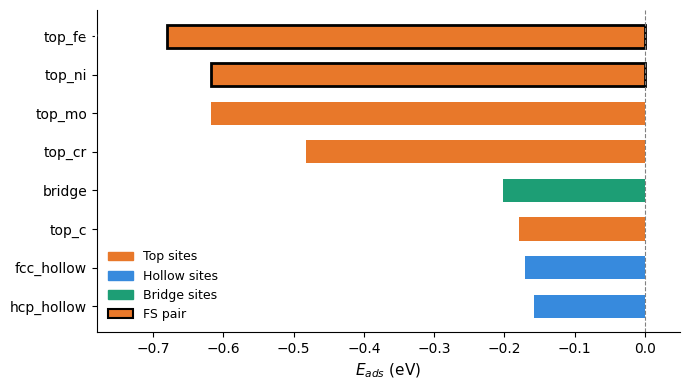

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = list(ranked)
values = [h_eads[site] for site in labels]

fs_pair      = {best1, best2}
top_sites    = {s for s in labels if s.startswith('top')}
hollow_sites = {s for s in labels if 'hollow' in s}
bridge_sites = {s for s in labels if 'bridge' in s}

def site_color(l):
    if l in top_sites:    return '#E8782A'
    if l in hollow_sites: return '#378ADD'
    return '#1D9E75'

colors      = [site_color(l) for l in labels]
edge_colors = ['black' if l in fs_pair else 'none' for l in labels]
linewidths  = [2.0      if l in fs_pair else 0.0   for l in labels]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, values, color=colors,
               edgecolor=edge_colors, linewidth=linewidths,
               height=0.6)

for bar, val, lbl in zip(bars, values, labels):
    bold = lbl in fs_pair
    ax.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f} eV', va='center', ha='right',
            fontsize=9, fontweight='bold' if bold else 'normal',
            color='white')

ax.invert_yaxis()
ax.set_xlabel('$E_{ads}$ (eV)', fontsize=11)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlim(min(values) - 0.1, 0.05)
ax.spines[['top', 'right']].set_visible(False)

legend = [
    mpatches.Patch(color='#E8782A', label='Top sites'),
    mpatches.Patch(color='#378ADD', label='Hollow sites'),
    mpatches.Patch(color='#1D9E75', label='Bridge sites'),
    mpatches.Patch(facecolor='#E8782A', edgecolor='black',
                   linewidth=1.5, label='FS pair'),
]
ax.legend(handles=legend, fontsize=9, frameon=False, loc='lower left')

plt.tight_layout()
plt.savefig('eads_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 — Build NEB Initial and Final States + Submit FS Minimization


In [10]:
# ─────────────────────────────────────────────────────────────
# IS: H2* at most stable NB05 adsorption site (best_adsorption_site.lammps)
# FS: 2H* at best1 and best2 from cell 3.3
#     — most stable non-adjacent single-H sites from explicit minimization
#     — H-H separation enforced > 2.5 A (fully dissociated criterion)
# FS is minimized with LAMMPS before the NEB runs.
# ─────────────────────────────────────────────────────────────

sc = SLURM_CONFIG
kk = ' '.join(KOKKOS_FLAGS)
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH' for p in sc['ld_paths'])

# ── IS: strip Velocities from NB05 best site relaxed structure ──
src_is = 'structures/notebook05-adsorption-energy/111/best_adsorption_site.lammps'
if not os.path.exists(src_is):
    raise FileNotFoundError(f'{src_is} not found. Complete Notebook 05 first.')

with open(src_is) as f:
    content = f.read()
if 'Velocities' in content:
    content = content[:content.index('Velocities')].rstrip() + '\n'
    print('Stripped Velocities from IS')
with open(NEB_IS_FILE, 'w') as f:
    f.write(content)
print(f'NEB IS written : {NEB_IS_FILE}')

# ── Read IS geometry ──────────────────────────────────────────
is_atoms     = read(NEB_IS_FILE, format='lammps-data', style='atomic')
is_pos       = is_atoms.get_positions()
is_syms      = np.array(is_atoms.get_chemical_symbols())
h_is         = is_pos[is_syms == 'H']
h2_center_xy = h_is[:, :2].mean(axis=0)
z_surf_is    = is_pos[is_syms != 'H', 2].max()
z_H2_actual  = h_is[:, 2].mean() - z_surf_is
cell         = is_atoms.cell.diagonal()

print(f'IS site           : {best_site_log}')
print(f'IS H2 center xy   : ({h2_center_xy[0]:.4f}, {h2_center_xy[1]:.4f})')
print(f'IS H2 height      : {z_H2_actual:+.4f} A above z_surf')
print(f'IS H-H dist       : {np.linalg.norm(h_is[0]-h_is[1]):.4f} A')

# ── FS: place H atoms at best1 and best2 from cell 3.3 ───────
x1, y1 = SITE_COORDS[best1]
x2, y2 = SITE_COORDS[best2]
z_fs   = z_surf_is + H_ATOM_HEIGHT

h1_fs = np.array([x1 % cell[0], y1 % cell[1], z_fs])
h2_fs = np.array([x2 % cell[0], y2 % cell[1], z_fs])

# Displacement of each H from IS center to FS site
d1 = np.linalg.norm(h_is[0, :2] - h1_fs[:2])
d2 = np.linalg.norm(h_is[1, :2] - h2_fs[:2])

print(f'\nFS site 1 : {best1:12s}  xy=({h1_fs[0]:.4f}, {h1_fs[1]:.4f})  disp={d1:.4f} A')
print(f'FS site 2 : {best2:12s}  xy=({h2_fs[0]:.4f}, {h2_fs[1]:.4f})  disp={d2:.4f} A')
print(f'H-H separation    : {sep_final:.4f} A')

# ── Build FS raw file ─────────────────────────────────────────
NEB_FS_RAW      = 'structures/notebook06-Neb-dissociation/111/neb_final_raw.lammps'
FS_RELAXED_DATA = 'structures/notebook06-Neb-dissociation/111/neb_final_relaxed.lammps'

metal_pos   = is_pos[is_syms != 'H']
metal_syms  = is_syms[is_syms != 'H']
fs_all_pos  = np.vstack([metal_pos, h1_fs, h2_fs])
fs_all_syms = np.concatenate([metal_syms, ['H', 'H']])

with open(NEB_FS_RAW, 'w') as f:
    f.write(f'# NEB FS: 2H* at {best1} + {best2} — Notebook 06\n\n')
    f.write(f'{len(fs_all_pos)} atoms\n8 atom types\n\n')
    f.write(f'0.0 {cell[0]:.10f} xlo xhi\n')
    f.write(f'0.0 {cell[1]:.10f} ylo yhi\n')
    f.write(f'0.0 {cell[2]:.10f} zlo zhi\n\n')
    f.write('Masses\n\n')
    for t, (m, el) in MASSES.items():
        f.write(f'{t} {m} # {el}\n')
    f.write('\nAtoms # atomic\n\n')
    for i, (sym, p) in enumerate(zip(fs_all_syms, fs_all_pos), 1):
        f.write(f'{i} {E2T[sym]} {p[0]:.10f} {p[1]:.10f} {p[2]:.10f}\n')
print(f'\nNEB FS raw written : {NEB_FS_RAW}')

# ── Write and submit FS minimization ─────────────────────────
fs_script = write_min_frozen('neb_final', NEB_FS_RAW, FS_RELAXED_DATA)

fs_slurm_lines = [
    '#!/bin/bash',
    '#SBATCH --job-name=nb06_neb_fs',
    f'#SBATCH --ntasks={sc["ntasks"]}',
    f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}',
    f'#SBATCH --gres=gpu:{sc["gpu"]}',
    f'#SBATCH --partition={sc["partition"]}',
    '#SBATCH --time=00:20:00',
    '#SBATCH --output=results/notebook06-Neb-dissociation/111/slurm_neb_final_%j.out',
    f'module load OpenMPI/{sc["openmpi_ver"]}',
    f'module load cuda/{sc["cuda_version"]}',
    'source ~/miniforge3/etc/profile.d/conda.sh',
    f'conda activate {sc["conda_env"]}',
    ld,
    f'cd {os.getcwd()}',
    f'{LAMMPS_CMD} {kk} -in {fs_script} -log results/notebook06-Neb-dissociation/111/neb_final_min.log',
    'echo "NEB FS done: $(date)"',
]
fs_slurm_path = 'slurm_scripts/notebook06-Neb-dissociation/111/run_neb_final.sh'
with open(fs_slurm_path, 'w') as f:
    f.write('\n'.join(fs_slurm_lines) + '\n')
os.chmod(fs_slurm_path, 0o755)

result_fs = subprocess.run(['sbatch', fs_slurm_path], capture_output=True, text=True)
jid_fs = result_fs.stdout.strip().split()[-1] if result_fs.returncode == 0 else 'FAIL'
print(f'FS minimization submitted -> Job {jid_fs}')
print(f'After job finishes (~5 min), run cell 3.5.')

Stripped Velocities from IS
NEB IS written : structures/notebook06-Neb-dissociation/111/neb_initial.lammps
IS site           : ads_bridge.log
IS H2 center xy   : (11.4318, 6.4592)
IS H2 height      : +2.9510 A above z_surf
IS H-H dist       : 0.7643 A

FS site 1 : top_fe        xy=(6.2073, 5.5820)  disp=4.9202 A
FS site 2 : top_ni        xy=(4.8435, 7.8026)  disp=7.0964 A
H-H separation    : 2.6059 A

NEB FS raw written : structures/notebook06-Neb-dissociation/111/neb_final_raw.lammps
FS minimization submitted -> Job 7257886
After job finishes (~5 min), run cell 3.5.


### 3.5 — Verify IS and FS

> Run after the FS minimization job finishes.
> Checks: 362 atoms, H-H molecular in IS, H-H dissociated in FS, delta_E < 0.

In [11]:
# ─────────────────────────────────────────────────────────────
# Verify IS and FS before running NEB
# IS: H2 molecular (H-H < 1.2 A), above surface
# FS: 2H dissociated (H-H > 2.5 A), dE < 0 (exothermic)
# ─────────────────────────────────────────────────────────────

FS_RELAXED_DATA = 'structures/notebook06-Neb-dissociation/111/neb_final_relaxed.lammps'
res_fs = parse_energy_log('results/notebook06-Neb-dissociation/111/neb_final_min.log')

print('IS / FS Verification')
print('=' * 65)

is_ok = False
fs_ok = False
E_FS  = None
delta_E = None

# ── IS ────────────────────────────────────────────────────────
if os.path.exists(NEB_IS_FILE):
    is_atoms     = read(NEB_IS_FILE, format='lammps-data', style='atomic')
    is_pos       = is_atoms.get_positions()
    is_syms      = np.array(is_atoms.get_chemical_symbols())
    h_is         = is_pos[is_syms == 'H']
    hh_is        = np.linalg.norm(h_is[0] - h_is[1])
    z_surf_v     = is_pos[is_syms != 'H', 2].max()
    depth_is     = z_surf_v - h_is[:, 2].mean()
    N_SLAB_ATOMS = len(is_atoms) - 2

    print(f'IS  (H2* at {best_site_log}):')
    print(f'  Atoms        : {len(is_atoms)}  (expect {N_SLAB_ATOMS + 2})')
    print(f'  H-H dist     : {hh_is:.4f} A  (molecular if < 1.2 A)')
    print(f'  H2 depth     : {depth_is:+.4f} A  (negative = above surface)')
    print(f'  Energy       : {E_IS:.6f} eV  [{best_site_log}]')
    is_ok = (len(is_atoms) == N_SLAB_ATOMS + 2 and hh_is < 1.2)
    print(f'  Status       : {"ok" if is_ok else "FAIL"}')
else:
    print('IS file not found — re-run cell 3.4')

print()

# ── FS ────────────────────────────────────────────────────────
if os.path.exists(FS_RELAXED_DATA) and res_fs:
    fs_atoms = read(FS_RELAXED_DATA, format='lammps-data', style='atomic')
    fs_pos   = fs_atoms.get_positions()
    fs_syms  = np.array(fs_atoms.get_chemical_symbols())
    h_fs     = fs_pos[fs_syms == 'H']
    hh_fs    = np.linalg.norm(h_fs[0] - h_fs[1])
    z_surf_v = fs_pos[fs_syms != 'H', 2].max()
    E_FS     = res_fs['pe_final_eV']
    delta_E  = E_FS - E_IS
    cell_v   = fs_atoms.cell.diagonal()

    disps = []
    for hi, hf in zip(h_is, h_fs):
        d = hf - hi
        d -= np.round(d / cell_v) * cell_v
        disps.append(np.linalg.norm(d))

    print(f'FS  (2H* at {best1} + {best2}):')
    print(f'  Atoms        : {len(fs_atoms)}  (expect {N_SLAB_ATOMS + 2})')
    print(f'  H-H dist     : {hh_fs:.4f} A  (dissociated if > 2.5 A)')
    for i, (hf, disp) in enumerate(zip(h_fs, disps)):
        print(f'  H_{i+1} depth   : {z_surf_v - hf[2]:+.4f} A  '
              f'disp from IS = {disp:.4f} A')
    print(f'  Energy       : {E_FS:.6f} eV  [neb_final_min.log]')
    print(f'  delta_E      : {delta_E:.4f} eV  '
          f'({"exothermic — ok" if delta_E < 0 else "endothermic — check FS"})')
    fs_ok = (len(fs_atoms) == N_SLAB_ATOMS + 2 and hh_fs > 2.5 and delta_E < 0)
    print(f'  Status       : {"ok" if fs_ok else "FAIL"}')
else:
    print('FS not ready — wait for neb_final job, then re-run this cell')

print()
print('=' * 65)
print(f'  {"ok" if is_ok else "FAIL"} IS : {N_SLAB_ATOMS + 2} atoms, H-H molecular, above surface')
print(f'  {"ok" if fs_ok else "FAIL"} FS : {N_SLAB_ATOMS + 2} atoms, H-H dissociated, dE < 0')
if is_ok and fs_ok:
    print()
    print(f'  E_IS    = {E_IS:.6f} eV')
    print(f'  E_FS    = {E_FS:.6f} eV')
    print(f'  delta_E = {delta_E:.4f} eV')
    print()
    print('  Both states verified — proceed to cell 3.7')
else:
    print('  Resolve FAIL items before proceeding')
print('=' * 65)

IS / FS Verification
IS  (H2* at ads_bridge.log):
  Atoms        : 362  (expect 362)
  H-H dist     : 0.7643 A  (molecular if < 1.2 A)
  H2 depth     : -2.9510 A  (negative = above surface)
  Energy       : -2393.710577 eV  [ads_bridge.log]
  Status       : ok

FS  (2H* at top_fe + top_ni):
  Atoms        : 362  (expect 362)
  H-H dist     : 2.9371 A  (dissociated if > 2.5 A)
  H_1 depth   : -0.2130 A  disp from IS = 4.4490 A
  H_2 depth   : -0.2821 A  disp from IS = 6.7211 A
  Energy       : -2394.805280 eV  [neb_final_min.log]
  delta_E      : -1.0947 eV  (exothermic — ok)
  Status       : ok

  ok IS : 362 atoms, H-H molecular, above surface
  ok FS : 362 atoms, H-H dissociated, dE < 0

  E_IS    = -2393.710577 eV
  E_FS    = -2394.805280 eV
  delta_E = -1.0947 eV

  Both states verified — proceed to cell 3.7


### 3.7 — Write ASE CINEB Script

> Single NEB from IS (H2* physisorbed) to FS (2H* dissociated).
> Uses IDPP interpolation — avoids atom clashes during dissociation [4].
> Two-phase: regular NEB (phase 1) then climbing image NEB (phase 2).
> Runs on 1 A100 GPU, MACECalculator called sequentially.

In [12]:
# ─────────────────────────────────────────────────────────────
# Write ASE CINEB script — single NEB IS to FS
# IS: H2* at bridge (z_surf+3.57 A, physisorbed)
# FS: 2H* at local hollows flanking bridge (minimized)
# Interpolation: IDPP — avoids atom clashes during dissociation [4]
# Two-phase: regular NEB (phase 1) then CINEB (phase 2)
# ─────────────────────────────────────────────────────────────

sc = SLURM_CONFIG
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
               for p in sc['ld_paths'])

FS_RELAXED_DATA = 'structures/notebook06-Neb-dissociation/111/neb_final_relaxed.lammps'

# Read E_FS from log
res_fs = parse_energy_log('results/notebook06-Neb-dissociation/111/neb_final_min.log')
if res_fs is None:
    raise FileNotFoundError('neb_final_min.log not found — run cell 3.4 first.')
E_FS = res_fs['pe_final_eV']

# ── Build script lines as a list — no f-string nesting ───────
neb06_py = [
    '#!/usr/bin/env python3',
    f'# ASE CINEB: H2 dissociation on Hastelloy N (111) — Notebook 06',
    f'# IS: H2* at {best_site_log}',
    f'# FS: 2H* at {best1} + {best2}',
    '# Interpolation: IDPP [4] — avoids atom clashes during dissociation',
    '# Two-phase: regular NEB (phase 1) then CINEB (phase 2)',
    '# Refs: NEB [1,2]; CINEB [3]; IDPP [4]; MACE [7]',
    '',
    'import os, sys, numpy as np, torch',
    'from ase.io import read',
    'from ase.mep import NEB',
    'from ase.optimize import MDMin',
    'from ase.calculators.singlepoint import SinglePointCalculator',
    'from mace.calculators import MACECalculator',
    '',
    '# Strip CUDA stubs from LD path — causes segfault on some nodes',
    '_ld = os.environ.get("LD_LIBRARY_PATH", "")',
    'os.environ["LD_LIBRARY_PATH"] = ":".join(',
    '    p for p in _ld.split(":") if "stubs" not in p)',
    '',
    '# ── Paths and parameters injected from notebook ──────────',
    f'MACE_MODEL      = "{MACE_MODEL_ASE}"',
    f'NEB_IS_FILE     = "{NEB_IS_FILE}"',
    f'FS_RELAXED_DATA = "{FS_RELAXED_DATA}"',
    f'Z_FREEZE_CUTOFF = {Z_FREEZE_CUTOFF}  # A — bottom layers frozen',
    f'E_IS            = {E_IS}             # eV — from NB05 minimization',
    f'E_FS            = {E_FS}             # eV — from NB06 FS minimization',
    f'N_IMAGES        = {N_REPLICAS}       # intermediate images',
    f'NEB_FMAX        = {NEB_FTOL}         # eV/A — CINEB convergence',
    f'N1_STEPS        = {N1_STEPS}         # phase 1 steps',
    f'NEB_STEPS       = {NEB_STEPS}        # phase 2 CINEB steps',
    f'SPRING_CONST    = {SPRING_CONST}     # elastic band, to keep image together',
    'N1_FMAX         = NEB_FMAX * 3       # looser fmax for phase 1',
    '',
    'device = "cuda" if torch.cuda.is_available() else "cpu"',
    'print(f"Device: {device}")',
    'sys.stdout.flush()',
    '',
    '# ── Freeze bottom slab layers — H atoms are above cutoff ─',
    'class MACEFrozenCalc(MACECalculator):',
    '    def get_forces(self, atoms=None):',
    '        forces = super().get_forces(atoms).copy()',
    '        a = self.atoms if atoms is None else atoms',
    '        forces[a.get_positions()[:, 2] < Z_FREEZE_CUTOFF] = 0.0',
    '        return forces',
    '',
    'def make_calc():',
    '    """Fresh calculator instance for each intermediate image."""',
    '    return MACEFrozenCalc(',
    '        model_paths=MACE_MODEL,',
    '        device=device,',
    '        default_dtype="float64",',
    '    )',
    '',
    '# ── Load IS and FS structures ─────────────────────────────',
    'print("Loading IS and FS...")',
    'is_raw = read(NEB_IS_FILE,     format="lammps-data", style="atomic")',
    'fs_raw = read(FS_RELAXED_DATA, format="lammps-data", style="atomic")',
    '',
    '# Endpoints use SinglePointCalculator — energies pinned, no re-evaluation',
    'is_end = is_raw.copy()',
    'is_end.calc = SinglePointCalculator(is_end)',
    'is_end.calc.results = {"energy": E_IS, "forces": np.zeros((len(is_end), 3))}',
    '',
    'fs_end = fs_raw.copy()',
    'fs_end.calc = SinglePointCalculator(fs_end)',
    'fs_end.calc.results = {"energy": E_FS, "forces": np.zeros((len(fs_end), 3))}',
    '',
    '# ── Build image chain — intermediates start from IS geometry',
    'images = [is_end]',
    'for _ in range(N_IMAGES):',
    '    img = is_raw.copy()',
    '    img.calc = make_calc()',
    '    images.append(img)',
    'images.append(fs_end)',
    '',
    'print(f"Images: {len(images)} total ({N_IMAGES} intermediate + IS + FS)")',
    'sys.stdout.flush()',
    '',
    '# ── IDPP interpolation — threads H atoms apart above surface',
    'neb = NEB(images, climb=False, k=1.0, method="aseneb")',
    'neb.interpolate(method="idpp")',
    '',
    'print("IDPP interpolation done. H-H distances along path:")',
    'for i, img in enumerate(images):',
    '    lbl = "IS" if i == 0 else ("FS" if i == len(images)-1 else f"img_{i}")',
    '    p = img.get_positions()',
    '    s = np.array(img.get_chemical_symbols())',
    '    h = p[s == "H"]',
    '    hh = np.linalg.norm(h[0]-h[1]) if len(h) == 2 else 0.0',
    '    print(f"  {lbl:6s}: H-H = {hh:.4f} A")',
    'sys.stdout.flush()',
    '',
    '# ── Phase 1: regular NEB — moves images onto MEP ─────────',
    'print(f"\\nPhase 1: regular NEB ({N1_STEPS} steps, fmax={N1_FMAX:.3f} eV/A)")',
    'sys.stdout.flush()',
    'opt1 = MDMin(neb, logfile="results/notebook06-Neb-dissociation/111/neb06_phase1.log", dt=0.05)',
    'opt1.run(fmax=N1_FMAX, steps=N1_STEPS)',
    # 'print(f"Phase 1 done: {opt1.nsteps} steps")',
    # 'sys.stdout.flush()',
    # '',
    # '# ── Phase 2: CINEB — pushes highest image to saddle point ─',
    # 'neb.climb = True',
    # 'print(f"\\nPhase 2: CINEB ({NEB_STEPS} steps, fmax={NEB_FMAX:.3f} eV/A)")',
    # 'sys.stdout.flush()',
    # 'opt2 = MDMin(neb, logfile="results/notebook06-Neb-dissociation/111/neb06_phase2.log", dt=0.02)',
    # 'opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)',
    # 'print(f"Phase 2 done: {opt2.nsteps} steps")',
    # 'sys.stdout.flush()',
    'print(f"Phase 1 done: {opt1.nsteps} steps")',
    'sys.stdout.flush()',
    '',
    '# Reset momenta before CINEB — prevents phase 1 velocity carryover',
    'for img in images[1:-1]:',
    '    img.set_momenta(np.zeros_like(img.get_momenta()))',
    '',
    '# ── Phase 2: CINEB — pushes highest image to saddle point ─',
    'neb.climb = True',
    'print(f"\\nPhase 2: CINEB ({NEB_STEPS} steps, fmax={NEB_FMAX:.3f} eV/A)")',
    'sys.stdout.flush()',
    'opt2 = MDMin(neb, logfile="results/notebook06-Neb-dissociation/111/neb06_phase2.log", dt=0.02)',
    'try:',
    '    opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)',
    'except Exception as e:',
    '    print(f"WARNING: phase 2 raised: {e}")',
    '    sys.stdout.flush()',
    'print(f"Phase 2 done: {opt2.nsteps} steps")',
    'sys.stdout.flush()',
    '',
    '# Read true fmax from phase 2 log — avoids NEB-projected force artifact',
    'with open("results/notebook06-Neb-dissociation/111/neb06_phase2.log", "r") as _f:',
    '    _last = [l for l in _f if l.strip()][-1]',
    'fmax_final = float(_last.split()[-1])',
    'converged  = fmax_final < NEB_FMAX',
    'print(f"fmax from log: {fmax_final:.4f} eV/A  Converged: {converged}")',
    'sys.stdout.flush()',
    '',
    '# ── Extract barrier and reaction energy ───────────────────',
    'energies = []',
    'for img in images:',
    '    try:    energies.append(img.get_potential_energy())',
    '    except: energies.append(None)',
    '',
    'valid   = [e for e in energies if e is not None]',
    'E_a     = max(valid) - E_IS',
    'dE      = E_FS - E_IS',
    '',
    'print(f"\\nNEB06 Results")',
    'print(f"  E_IS     : {E_IS:.6f} eV")',
    'print(f"  E_FS     : {E_FS:.6f} eV")',
    'print(f"  E_a      : {E_a:.4f} eV")',
    'print(f"  delta_E  : {dE:.4f} eV")',
    'print(f"  fmax     : {fmax_final:.4f} eV/A")',
    'print(f"  Converged: {converged}")',
    'sys.stdout.flush()',
    '',
    '# ── Write intermediate image structures ──────────────────',
    'from ase.io import write as ase_write',
    'img_dir = "structures/notebook06-Neb-dissociation/111/neb_images"',
    'os.makedirs(img_dir, exist_ok=True)',
    '',
    'for i, img in enumerate(images[1:-1], start=1):',
    '    img.info["energy_eV"]  = energies[i]',
    '    img.info["dE_from_IS"] = energies[i] - E_IS',
    '    img.info["image_index"] = i',
    '    fpath = os.path.join(img_dir, f"neb_img_{i:02d}.lammps")',
    '    ase_write(fpath, img, format="lammps-data")',
    '',
    '# Full trajectory (IS + intermediates + FS) for OVITO',
    'traj_path = "results/notebook06-Neb-dissociation/111/neb_path.extxyz"',
    'ase_write(traj_path, images, format="extxyz")',
    '',
    'print(f"Written {len(images)-2} intermediate structures to {img_dir}")',
    'print(f"Trajectory written to {traj_path}")',
    'sys.stdout.flush()',


    '# ── Write output files ────────────────────────────────────',
    'barrier_file = "results/notebook06-Neb-dissociation/111/neb_barrier.txt"',
    'path_file    = "results/notebook06-Neb-dissociation/111/neb_path.dat"',
    '',
    'with open(barrier_file, "w", encoding="utf-8") as f:',
    f'    f.write("IS : H2* at {best_site_log}\\n")',
    f'    f.write("FS : 2H* at {best1} + {best2}\\n")',
    '    f.write("Interpolation: IDPP\\n")',
    '    f.write(f"N images    : {len(images)} ({N_IMAGES} intermediate + IS + FS)\\n")',
    '    f.write(f"fmax_final  : {fmax_final:.4f} eV/A\\n")',
    '    f.write(f"Converged   : {converged}\\n\\n")',
    '    f.write(f"E_IS    = {E_IS:.6f} eV\\n")',
    '    f.write(f"E_FS    = {E_FS:.6f} eV\\n")',
    '    f.write(f"E_a     = {E_a:.4f} eV\\n")',
    '    f.write(f"delta_E = {dE:.4f} eV\\n\\n")',
    '    f.write("Image energies:\\n")',
    '    for i, e in enumerate(energies):',
    '        lbl = "IS" if i == 0 else ("FS" if i == len(energies)-1 else f"img_{i}")',
    '        if e is not None:',
    '            f.write(f"  {lbl:6s}: {e:.6f} eV  ({e-E_IS:+.4f} eV)\\n")',
    '',
    'with open(path_file, "w", encoding="utf-8") as f:',
    '    f.write("# image  E(eV)  dE_from_IS(eV)\\n")',
    '    n = len(energies)',
    '    for i, e in enumerate(energies):',
    '        if e is not None:',
    '            f.write(f"{i/(n-1):.4f}  {e:.6f}  {e-E_IS:+.4f}\\n")',
    '',
    'print("Saved: " + barrier_file)',
    'print("Saved: " + path_file)',
]

neb06_py_path = 'lammps_scripts/notebook06-Neb-dissociation/111/run_ase_neb06.py'
with open(neb06_py_path, 'w') as f:
    f.write('\n'.join(neb06_py) + '\n')

print(f'Written : {neb06_py_path}')
print(f'  IS    : {NEB_IS_FILE}')
print(f'  FS    : {FS_RELAXED_DATA}')
print(f'  E_IS  : {E_IS:.6f} eV')
print(f'  E_FS  : {E_FS:.6f} eV')
print(f'  Images: {N_REPLICAS} intermediate + IS + FS = {N_REPLICAS+2} total')
print(f'  Interp: IDPP')
print(f'  Phase1: {N1_STEPS} steps, fmax={NEB_FTOL*3:.3f} eV/A')
print(f'  Phase2: {NEB_STEPS} steps, fmax={NEB_FTOL:.3f} eV/A (CINEB)')
print()
print('Run cell 3.8 to submit.')

Written : lammps_scripts/notebook06-Neb-dissociation/111/run_ase_neb06.py
  IS    : structures/notebook06-Neb-dissociation/111/neb_initial.lammps
  FS    : structures/notebook06-Neb-dissociation/111/neb_final_relaxed.lammps
  E_IS  : -2393.710577 eV
  E_FS  : -2394.805280 eV
  Images: 18 intermediate + IS + FS = 20 total
  Interp: IDPP
  Phase1: 5000 steps, fmax=0.150 eV/A
  Phase2: 10000 steps, fmax=0.050 eV/A (CINEB)

Run cell 3.8 to submit.


### 3.8 — Submit NEB Job

> 1 A100 GPU, ~1-2 hours. After job finishes, run cell 3.9.

In [13]:
# ─────────────────────────────────────────────────────────────
# Submit ASE CINEB job — 1 A100, sequential force calls
# ─────────────────────────────────────────────────────────────

sc = SLURM_CONFIG
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
               for p in sc['ld_paths'])

neb06_slurm = f"""#!/bin/bash
#SBATCH --job-name=nb06_neb
#SBATCH --ntasks=1
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:a100:1
#SBATCH --partition={sc['partition']}
#SBATCH --output=results/notebook06-Neb-dissociation/111/slurm_neb06_%j.out

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}
source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}
{ld}
cd {os.getcwd()}

echo "Node: $(hostname)  Start: $(date)"
python {neb06_py_path}
echo "End: $(date)"
"""

neb06_slurm_path = 'slurm_scripts/notebook06-Neb-dissociation/111/run_neb06.sh'
with open(neb06_slurm_path, 'w') as f:
    f.write(neb06_slurm)
os.chmod(neb06_slurm_path, 0o755)

result = subprocess.run(['sbatch', neb06_slurm_path],
                        capture_output=True, text=True)
if result.returncode == 0:
    jid = result.stdout.strip().split()[-1]
    print(f'NEB06 submitted -> Job {jid}')
    print(f'Monitor : tail -f results/notebook06-Neb-dissociation/111/slurm_neb06_{jid}.out')
    print(f'Expected: ~1-2 hours on 1 A100')
else:
    print(f'Submission failed: {result.stderr.strip()}')

NEB06 submitted -> Job 7258810
Monitor : tail -f results/notebook06-Neb-dissociation/111/slurm_neb06_7258810.out
Expected: ~1-2 hours on 1 A100


### 3.9 — Parse NEB Results

In [15]:
# ─────────────────────────────────────────────────────────────
# Parse NEB06 results from barrier file and path file
# Written by run_ase_neb06.py after job completes
# ─────────────────────────────────────────────────────────────

BARRIER_FILE  = 'results/notebook06-Neb-dissociation/111/neb_barrier.txt'
PATH_FILE     = 'results/notebook06-Neb-dissociation/111/neb_path.dat'

def parse_barrier_file(path):
    """Parse both = and : delimited lines from barrier txt file."""
    d = {}
    if not os.path.exists(path):
        return None
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            if '=' in line:
                k, _, v = line.partition('=')
                try:
                    d[k.strip()] = float(v.strip().split()[0])
                except ValueError:
                    pass
            if ':' in line:
                k, _, v = line.partition(':')
                k = k.strip()
                if k in ('fmax_final', 'Converged', 'N images', 'Interpolation'):
                    d[k] = v.strip()
    return d if d else None

def parse_neb_path(path_file):
    if not os.path.exists(path_file):
        return None
    data = []
    with open(path_file) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            try:
                data.append([float(x) for x in line.split()])
            except:
                pass
    return np.array(data) if data else None

barrier       = parse_barrier_file(BARRIER_FILE)
neb_path_data = parse_neb_path(PATH_FILE)

print('NEB06 Results')
print('=' * 60)

if barrier is None:
    print('neb_barrier.txt not found — job may still be running')
    print('Monitor: tail -f results/notebook06-Neb-dissociation/111/slurm_neb06_*.out')
else:
    E_a       = barrier.get('E_a')
    delta_E   = barrier.get('delta_E')
    E_FS      = barrier.get('E_FS')
    fmax_str  = barrier.get('fmax_final', 'unknown')
    converged = barrier.get('Converged',  'unknown')

    print(f'  E_IS        : {E_IS:.6f} eV')
    print(f'  E_FS        : {E_FS:.6f} eV')
    print(f'  E_a         : {E_a:.4f} eV')
    print(f'  delta_E     : {delta_E:.4f} eV  '
          f'({"exothermic" if delta_E < 0 else "endothermic"})')
    print(f'  fmax_final  : {fmax_str}')
    print(f'  Converged   : {converged}')
    print()

    if E_a < 0.1:
        print('  → H2 dissociates near-barrierlessly at 300 K')
    elif E_a < 0.5:
        print('  → Small barrier — dissociation occurs readily at 300 K')
    elif E_a < 1.0:
        print('  → Moderate barrier — dissociation is rate-limited')
    else:
        print('  → Large barrier — check path for unphysical geometries')
    print()

if neb_path_data is not None:
    print(f'  Path: {len(neb_path_data)} images loaded from {PATH_FILE}')
else:
    print('  Path data not found — available after job completes')

print('=' * 60)

NEB06 Results
  E_IS        : -2393.710577 eV
  E_FS        : -2394.805280 eV
  E_a         : 0.3362 eV
  delta_E     : -1.0947 eV  (exothermic)
  fmax_final  : 0.0497 eV/A
  Converged   : True

  → Small barrier — dissociation occurs readily at 300 K

  Path: 20 images loaded from results/notebook06-Neb-dissociation/111/neb_path.dat


### 3.10 — Plot MEP

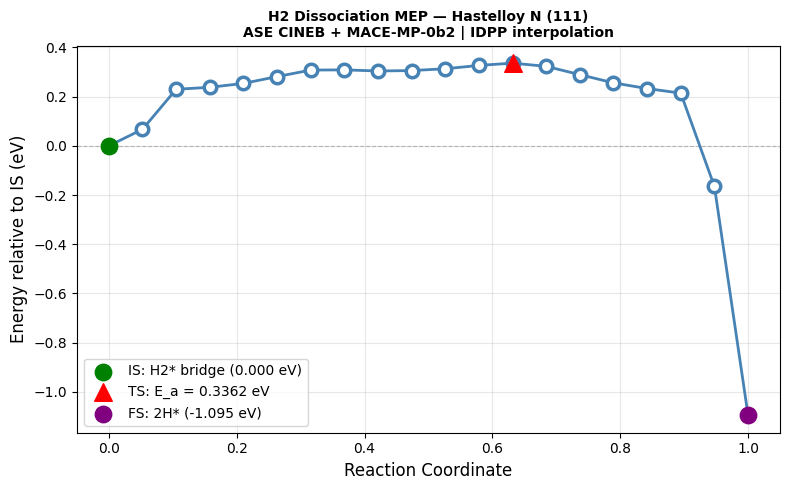

Saved: results/notebook06-Neb-dissociation/111/fig_mep.png

E_a     = 0.3362 eV  (TS at image 12)
delta_E = -1.0947 eV


In [16]:
# ─────────────────────────────────────────────────────────────
# Plot minimum energy path (MEP)
# ─────────────────────────────────────────────────────────────

if neb_path_data is None or len(neb_path_data) == 0:
    print('neb_path.dat not found — run NEB job first.')
else:
    rxn_coord = neb_path_data[:, 0]   # image fraction 0->1
    e_rel     = neb_path_data[:, 2]   # dE from IS in eV
    ts_idx    = int(np.argmax(e_rel))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(rxn_coord, e_rel, 'o-', color='steelblue',
            lw=2, ms=9, mfc='white', mew=2.5, zorder=3)
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)

    ax.scatter([rxn_coord[0]], [e_rel[0]], s=140,
               color='green', zorder=5,
               label=f'IS: H2* bridge ({e_rel[0]:.3f} eV)')
    ax.scatter([rxn_coord[ts_idx]], [e_rel[ts_idx]], s=160,
               color='red', marker='^', zorder=5,
               label=f'TS: E_a = {e_rel[ts_idx]:.4f} eV')
    ax.scatter([rxn_coord[-1]], [e_rel[-1]], s=140,
               color='purple', zorder=5,
               label=f'FS: 2H* ({e_rel[-1]:.3f} eV)')

    ax.set_xlabel('Reaction Coordinate', fontsize=12)
    ax.set_ylabel('Energy relative to IS (eV)', fontsize=12)
    ax.set_title('H2 Dissociation MEP — Hastelloy N (111)\n'
                 'ASE CINEB + MACE-MP-0b2 | IDPP interpolation',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/notebook06-Neb-dissociation/111/fig_mep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook06-Neb-dissociation/111/fig_mep.png')
    print()
    print(f'E_a     = {e_rel[ts_idx]:.4f} eV  (TS at image {ts_idx})')
    print(f'delta_E = {e_rel[-1]:.4f} eV')

### 3.11 — Decision Cell

In [12]:
# ─────────────────────────────────────────────────────────────
# Notebook 06 — Final Decision
# ─────────────────────────────────────────────────────────────

print('=' * 62)
print('  NOTEBOOK 06 — FINAL DECISION')
print('=' * 62)

E_a_final  = barrier.get('E_a')     if barrier else None
dE_final   = barrier.get('delta_E') if barrier else None
E_FS_final = barrier.get('E_FS')    if barrier else None

checks = [
    ('IS file exists',
     os.path.exists(NEB_IS_FILE)),
    ('FS relaxed file exists',
     os.path.exists('structures/notebook06-Neb-dissociation/111/neb_final_relaxed.lammps')),
    ('NEB barrier file written',
     os.path.exists(BARRIER_FILE)),
    ('NEB path file written',
     os.path.exists(PATH_FILE)),
    ('E_a extracted',
     E_a_final is not None),
    ('E_a physical (0 to 2 eV)',
     E_a_final is not None and 0.0 <= E_a_final <= 2.0),
    ('delta_E negative (exothermic)',
     dE_final is not None and dE_final < 0),
    ('MEP plot saved',
     os.path.exists('results/notebook06-Neb-dissociation/111/fig_mep.png')),
]

all_pass = True
for label, ok in checks:
    print(f'  {"ok" if ok else "FAIL"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  ALL CHECKS PASSED')
    print()
    print(f'  IS              : H2* at bridge (physisorbed, z_surf+3.57 A)')
    print(f'  FS              : 2H* at local hollows flanking bridge')
    print(f'  E_IS            : {E_IS:.6f} eV')
    print(f'  E_FS            : {E_FS_final:.6f} eV')
    print(f'  E_a             : {E_a_final:.4f} eV')
    print(f'  delta_E         : {dE_final:.4f} eV  (exothermic)')
    print()
    print('  Physical interpretation:')
    if E_a_final < 0.1:
        print('  H2 dissociates barrierlessly — surface is highly reactive')
    elif E_a_final < 0.5:
        print('  Small barrier — H2 dissociates readily at 300 K')
    elif E_a_final < 1.0:
        print('  Moderate barrier — dissociation is rate-limited at 300 K')
    print()
    print('  Proceed to Notebook 07 (Surface Coverage)')
else:
    print('  CHECKS FAILED — resolve all FAIL items above')

print('=' * 62)

  NOTEBOOK 06 — FINAL DECISION
  ok IS file exists
  ok FS relaxed file exists
  ok NEB barrier file written
  ok NEB path file written
  ok E_a extracted
  ok E_a physical (0 to 2 eV)
  ok delta_E negative (exothermic)
  ok MEP plot saved

  ALL CHECKS PASSED

  IS              : H2* at bridge (physisorbed, z_surf+3.57 A)
  FS              : 2H* at local hollows flanking bridge
  E_IS            : -2398.201099 eV
  E_FS            : -2399.449759 eV
  E_a             : 0.3839 eV
  delta_E         : -1.2487 eV  (exothermic)

  Physical interpretation:
  Small barrier — H2 dissociates readily at 300 K

  Proceed to Notebook 07 (Surface Coverage)
